In [3]:
import sys
print("Python:", sys.version)
print("Todo funciona ✓")


Python: 3.13.13 (tags/v3.13.13:01104ce, Apr  7 2026, 19:25:48) [MSC v.1944 64 bit (AMD64)]
Todo funciona ✓


In [4]:
import subprocess
subprocess.run(["pip", "install", "torch", "torchvision", "rasterio", "matplotlib"])

CompletedProcess(args=['pip', 'install', 'torch', 'torchvision', 'rasterio', 'matplotlib'], returncode=0)

In [5]:
import torch
import torchvision
import rasterio
import matplotlib

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Rasterio:", rasterio.__version__)
print("Matplotlib:", matplotlib.__version__)
print("¿GPU disponible?:", torch.cuda.is_available())

PyTorch: 2.12.0+cpu
Torchvision: 0.27.0+cpu
Rasterio: 1.5.0
Matplotlib: 3.10.9
¿GPU disponible?: False


In [6]:
import json

with open("../outputs/alerts_20260608.geojson", "r") as f:
    alerts = json.load(f)

# Ver cuántas alertas hay y cómo luce una
print("Total de alertas:", len(alerts["features"]))
print("\nEjemplo de una alerta:")
print(json.dumps(alerts["features"][0], indent=2))

Total de alertas: 1642

Ejemplo de una alerta:
{
  "type": "Feature",
  "geometry": {
    "type": "Polygon",
    "coordinates": [
      [
        [
          -73.50516411790409,
          -3.2046079323374377
        ],
        [
          -73.49950726365459,
          -3.2046079323374377
        ],
        [
          -73.49950726365459,
          -3.2017795052126914
        ],
        [
          -73.50516411790409,
          -3.2017795052126914
        ],
        [
          -73.50516411790409,
          -3.2046079323374377
        ]
      ]
    ]
  },
  "properties": {
    "id": "b8d88c6b-b6b9-4711-9c2c-516587e4c6f4",
    "lat": -3.203194,
    "lon": -73.502336,
    "detection_date": "2026-06-08",
    "severity": "low",
    "ndvi_change": 0.2159,
    "area_ha": 19.75
  }
}


In [7]:
from collections import Counter

severidades = [f["properties"]["severity"] for f in alerts["features"]]
conteo = Counter(severidades)

print("Distribución de alertas:")
for severidad, cantidad in conteo.items():
    print(f"  {severidad}: {cantidad} alertas")

Distribución de alertas:
  low: 1232 alertas
  medium: 363 alertas
  high: 47 alertas


In [8]:
import sys
sys.path.append("../")  # para que encuentre los archivos de SentinelWatch

import ee
import gee_client

print("GEE conectado ✓")

GEE conectado ✓


In [9]:
import os

# Crear estructura de carpetas
carpetas = [
    "../model/data/low",
    "../model/data/medium", 
    "../model/data/high"
]

for carpeta in carpetas:
    os.makedirs(carpeta, exist_ok=True)
    print(f"✓ Creada: {carpeta}")

print("\nEstructura lista")


✓ Creada: ../model/data/low
✓ Creada: ../model/data/medium
✓ Creada: ../model/data/high

Estructura lista


In [10]:
import ee
import requests
import numpy as np
import rasterio
from rasterio.transform import from_bounds

def descargar_imagen(alerta, carpeta_destino, idx):
    """Descarga imagen Sentinel-2 para una alerta y la guarda como .tif"""
    
    # 1. Obtener coordenadas y fecha
    coords = alerta["geometry"]["coordinates"][0]
    props = alerta["properties"]
    
    # 2. Crear geometría en GEE
    geometria = ee.Geometry.Polygon(coords)
    
    # 3. Buscar imagen Sentinel-2 de esa zona
    imagen = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(geometria)
        .filterDate("2024-01-01", "2025-01-01")
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
        .median()
        .select(["B4", "B3", "B2", "B8"])  # RGB + NIR
    )
    
    # 4. Descargar como array
    url = imagen.getDownloadURL({
        "region": geometria,
        "scale": 10,
        "format": "NPY"
    })
    
    response = requests.get(url)
    data = np.load(io.BytesIO(response.content))
    
    # 5. Guardar como .tif
    archivo = os.path.join(carpeta_destino, f"alerta_{idx:04d}.tif")
    
    with rasterio.open(
        archivo, "w",
        driver="GTiff",
        height=data.shape[0],
        width=data.shape[1],
        count=4,
        dtype=data.dtype
    ) as dst:
        for i in range(4):
            dst.write(data[:,:,i], i+1)
    
    return archivo

# Probar con las primeras 10 alertas
import io

print("Descargando 10 alertas de prueba...")
for i, alerta in enumerate(alerts["features"][:10]):
    severidad = alerta["properties"]["severity"]
    carpeta = f"../model/data/{severidad}"
    
    try:
        archivo = descargar_imagen(alerta, carpeta, i)
        print(f"  ✓ Alerta {i+1}/10 — {severidad} — guardada")
    except Exception as e:
        print(f"  ✗ Alerta {i+1}/10 — error: {e}")

print("\nPrueba terminada")

Descargando 10 alertas de prueba...
  ✗ Alerta 1/10 — error: Earth Engine client library not initialized. See http://goo.gle/ee-auth.
  ✗ Alerta 2/10 — error: Earth Engine client library not initialized. See http://goo.gle/ee-auth.
  ✗ Alerta 3/10 — error: Earth Engine client library not initialized. See http://goo.gle/ee-auth.
  ✗ Alerta 4/10 — error: Earth Engine client library not initialized. See http://goo.gle/ee-auth.
  ✗ Alerta 5/10 — error: Earth Engine client library not initialized. See http://goo.gle/ee-auth.
  ✗ Alerta 6/10 — error: Earth Engine client library not initialized. See http://goo.gle/ee-auth.
  ✗ Alerta 7/10 — error: Earth Engine client library not initialized. See http://goo.gle/ee-auth.
  ✗ Alerta 8/10 — error: Earth Engine client library not initialized. See http://goo.gle/ee-auth.
  ✗ Alerta 9/10 — error: Earth Engine client library not initialized. See http://goo.gle/ee-auth.
  ✗ Alerta 10/10 — error: Earth Engine client library not initialized. See http://

In [11]:
import inspect
print(inspect.getsource(gee_client))


import ee
import numpy as np

from config import AOI, CLOUD_COVER_MAX


def aoi_geometry() -> ee.Geometry:
    """Returns the area of interest as a GEE Rectangle."""
    west, south, east, north = AOI
    return ee.Geometry.BBox(west, south, east, north)


def get_sentinel2_collection(
    aoi: ee.Geometry,
    start: str,
    end: str,
    cloud_pct: int = CLOUD_COVER_MAX,
) -> ee.ImageCollection:
    """Loads a cloud-filtered Sentinel-2 SR collection.

    Uses the COPERNICUS/S2_SR_HARMONIZED dataset, which applies
    radiometric harmonization across processing baselines so that
    images from different years are directly comparable.

    Args:
        aoi:       GEE geometry to filter by bounds.
        start:     Start date string, e.g. "2023-06-01".
        end:       End date string, e.g. "2023-08-31".
        cloud_pct: Maximum allowed cloud cover percentage per image.

    Returns:
        Filtered ee.ImageCollection.
    """
    return (
        ee.ImageCollection("COPERNICU

In [12]:
import inspect
import auth
print(inspect.getsource(auth))


import ee


def authenticate() -> None:
    """Runs browser-based OAuth flow and saves credentials locally.

    Only needs to run once. Credentials are stored at:
      Windows: C:\\Users\\<user>\\.config\\earthengine\\credentials
    Subsequent calls to initialize() reuse the saved token automatically.
    """
    ee.Authenticate()


DEFAULT_PROJECT = "gen-lang-client-0350293091"


def initialize(project: str | None = None) -> None:
    """Initializes the GEE client using saved credentials.

    Args:
        project: GEE Cloud project ID. Defaults to DEFAULT_PROJECT.
    """
    ee.Initialize(project=project or DEFAULT_PROJECT)
    print("Google Earth Engine initialized successfully.")


def authenticate_and_initialize(project: str | None = None) -> None:
    """Convenience wrapper: authenticate if needed, then initialize.

    Safe to call on every run — if valid credentials already exist,
    ee.Authenticate() is a no-op and Initialize proceeds immediately.
    """
    authenticat

In [13]:
import auth
auth.initialize()


Google Earth Engine initialized successfully.


In [14]:
import ee
import requests
import numpy as np
import rasterio
from rasterio.transform import from_bounds

def descargar_imagen(alerta, carpeta_destino, idx):
    """Descarga imagen Sentinel-2 para una alerta y la guarda como .tif"""
    
    # 1. Obtener coordenadas y fecha
    coords = alerta["geometry"]["coordinates"][0]
    props = alerta["properties"]
    
    # 2. Crear geometría en GEE
    geometria = ee.Geometry.Polygon(coords)
    
    # 3. Buscar imagen Sentinel-2 de esa zona
    imagen = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(geometria)
        .filterDate("2024-01-01", "2025-01-01")
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
        .median()
        .select(["B4", "B3", "B2", "B8"])  # RGB + NIR
    )
    
    # 4. Descargar como array
    url = imagen.getDownloadURL({
        "region": geometria,
        "scale": 10,
        "format": "NPY"
    })
    
    response = requests.get(url)
    data = np.load(io.BytesIO(response.content))
    
    # 5. Guardar como .tif
    archivo = os.path.join(carpeta_destino, f"alerta_{idx:04d}.tif")
    
    with rasterio.open(
        archivo, "w",
        driver="GTiff",
        height=data.shape[0],
        width=data.shape[1],
        count=4,
        dtype=data.dtype
    ) as dst:
        for i in range(4):
            dst.write(data[:,:,i], i+1)
    
    return archivo

# Probar con las primeras 10 alertas
import io

print("Descargando 10 alertas de prueba...")
for i, alerta in enumerate(alerts["features"][:10]):
    severidad = alerta["properties"]["severity"]
    carpeta = f"../model/data/{severidad}"
    
    try:
        archivo = descargar_imagen(alerta, carpeta, i)
        print(f"  ✓ Alerta {i+1}/10 — {severidad} — guardada")
    except Exception as e:
        print(f"  ✗ Alerta {i+1}/10 — error: {e}")

print("\nPrueba terminada")

Descargando 10 alertas de prueba...
  ✗ Alerta 1/10 — error: invalid dtype: dtype([('B4', '<f8'), ('B3', '<f8'), ('B2', '<f8'), ('B8', '<f8')])
  ✗ Alerta 2/10 — error: invalid dtype: dtype([('B4', '<f8'), ('B3', '<f8'), ('B2', '<f8'), ('B8', '<f8')])
  ✗ Alerta 3/10 — error: invalid dtype: dtype([('B4', '<f8'), ('B3', '<f8'), ('B2', '<f8'), ('B8', '<f8')])
  ✗ Alerta 4/10 — error: invalid dtype: dtype([('B4', '<f8'), ('B3', '<f8'), ('B2', '<f8'), ('B8', '<f8')])
  ✗ Alerta 5/10 — error: invalid dtype: dtype([('B4', '<f8'), ('B3', '<f8'), ('B2', '<f8'), ('B8', '<f8')])
  ✗ Alerta 6/10 — error: invalid dtype: dtype([('B4', '<f8'), ('B3', '<f8'), ('B2', '<f8'), ('B8', '<f8')])
  ✗ Alerta 7/10 — error: invalid dtype: dtype([('B4', '<f8'), ('B3', '<f8'), ('B2', '<f8'), ('B8', '<f8')])
  ✗ Alerta 8/10 — error: invalid dtype: dtype([('B4', '<f8'), ('B3', '<f8'), ('B2', '<f8'), ('B8', '<f8')])
  ✗ Alerta 9/10 — error: invalid dtype: dtype([('B4', '<f8'), ('B3', '<f8'), ('B2', '<f8'), ('B8', '

In [15]:
def descargar_imagen(alerta, carpeta_destino, idx):
    coords = alerta["geometry"]["coordinates"][0]
    props = alerta["properties"]
    
    geometria = ee.Geometry.Polygon(coords)
    
    imagen = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(geometria)
        .filterDate("2024-01-01", "2025-01-01")
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
        .median()
        .select(["B4", "B3", "B2", "B8"])
    )
    
    url = imagen.getDownloadURL({
        "region": geometria,
        "scale": 10,
        "format": "NPY"
    })
    
    response = requests.get(url)
    data = np.load(io.BytesIO(response.content))
    
    # Convertir array estructurado a array normal
    data = np.stack([data["B4"], data["B3"], data["B2"], data["B8"]], axis=-1)
    data = data.astype(np.float32)
    
    archivo = os.path.join(carpeta_destino, f"alerta_{idx:04d}.tif")
    
    with rasterio.open(
        archivo, "w",
        driver="GTiff",
        height=data.shape[0],
        width=data.shape[1],
        count=4,
        dtype=data.dtype
    ) as dst:
        for i in range(4):
            dst.write(data[:,:,i], i+1)
    
    return archivo

# Probar de nuevo
print("Descargando 10 alertas de prueba...")
for i, alerta in enumerate(alerts["features"][:10]):
    severidad = alerta["properties"]["severity"]
    carpeta = f"../model/data/{severidad}"
    
    try:
        archivo = descargar_imagen(alerta, carpeta, i)
        print(f"  ✓ Alerta {i+1}/10 — {severidad} — guardada")
    except Exception as e:
        print(f"  ✗ Alerta {i+1}/10 — error: {e}")

print("\nPrueba terminada")


Descargando 10 alertas de prueba...


c:\Users\juanc\OneDrive\Documentos\SentinelWatch\.venv\Lib\site-packages\rasterio\__init__.py:389: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(


  ✓ Alerta 1/10 — low — guardada
  ✓ Alerta 2/10 — low — guardada
  ✓ Alerta 3/10 — medium — guardada
  ✓ Alerta 4/10 — low — guardada
  ✓ Alerta 5/10 — low — guardada
  ✓ Alerta 6/10 — low — guardada
  ✓ Alerta 7/10 — medium — guardada
  ✓ Alerta 8/10 — high — guardada
  ✓ Alerta 9/10 — medium — guardada
  ✓ Alerta 10/10 — low — guardada

Prueba terminada


c:\Users\juanc\OneDrive\Documentos\SentinelWatch\.venv\Lib\site-packages\rasterio\__init__.py:379: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


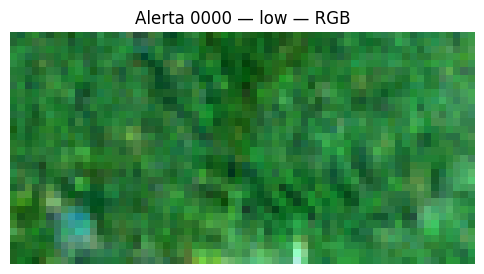

Tamaño de la imagen: (4, 32, 64)


In [16]:
import matplotlib.pyplot as plt
import rasterio
import numpy as np

# Abrir la primera imagen descargada
with rasterio.open("../model/data/low/alerta_0000.tif") as src:
    img = src.read()  # shape: (4, height, width)

# Mostrar las bandas RGB (B4, B3, B2)
rgb = np.stack([img[0], img[1], img[2]], axis=-1)

# Normalizar para visualizar
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())

plt.figure(figsize=(6, 6))
plt.imshow(rgb)
plt.title("Alerta 0000 — low — RGB")
plt.axis("off")
plt.show()

print("Tamaño de la imagen:", img.shape)

In [19]:
from skimage.transform import resize

def descargar_imagen_v2(alerta, carpeta_destino, idx):
    coords = alerta["geometry"]["coordinates"][0]
    
    geometria = ee.Geometry.Polygon(coords)
    
    imagen = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(geometria)
        .filterDate("2024-01-01", "2025-01-01")
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
        .median()
        .select(["B4", "B3", "B2", "B8"])
    )
    
    url = imagen.getDownloadURL({
        "region": geometria,
        "scale": 10,
        "format": "NPY"
    })
    
    response = requests.get(url)
    data = np.load(io.BytesIO(response.content))
    data = np.stack([data["B4"], data["B3"], data["B2"], data["B8"]], axis=-1)
    data = data.astype(np.float32)
    
    # Redimensionar a 64x64
    data = resize(data, (64, 64, 4), anti_aliasing=True).astype(np.float32)
    
    archivo = os.path.join(carpeta_destino, f"alerta_{idx:04d}.tif")
    
    with rasterio.open(
        archivo, "w",
        driver="GTiff",
        height=64, width=64,
        count=4,
        dtype=np.float32
    ) as dst:
        for i in range(4):
            dst.write(data[:,:,i], i+1)
    
    return archivo

print("Probando versión 2 con 5 alertas...")
for i, alerta in enumerate(alerts["features"][:5]):
    severidad = alerta["properties"]["severity"]
    carpeta = f"../model/data/{severidad}"
    
    try:
        archivo = descargar_imagen_v2(alerta, carpeta, i)
        print(f"  ✓ Alerta {i+1}/5 — {severidad} — guardada")
    except Exception as e:
        print(f"  ✗ Alerta {i+1}/5 — error: {e}")

Probando versión 2 con 5 alertas...


c:\Users\juanc\OneDrive\Documentos\SentinelWatch\.venv\Lib\site-packages\rasterio\__init__.py:389: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(


  ✓ Alerta 1/5 — low — guardada
  ✓ Alerta 2/5 — low — guardada
  ✓ Alerta 3/5 — medium — guardada
  ✓ Alerta 4/5 — low — guardada
  ✓ Alerta 5/5 — low — guardada


In [18]:
import subprocess
subprocess.run(["pip", "install", "scikit-image"])


CompletedProcess(args=['pip', 'install', 'scikit-image'], returncode=0)

In [20]:
with rasterio.open("../model/data/low/alerta_0000.tif") as src:
    img = src.read()

print("Tamaño:", img.shape)  # debe decir (4, 64, 64)


Tamaño: (4, 64, 64)


c:\Users\juanc\OneDrive\Documentos\SentinelWatch\.venv\Lib\site-packages\rasterio\__init__.py:379: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


In [1]:
import sys
print("Python:", sys.version)

import subprocess
result = subprocess.run(["nvidia-smi"], capture_output=True, text=True)
print(result.stdout)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Mon Jun  8 17:09:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |             

In [2]:
import subprocess
subprocess.run(["pip", "install", "earthengine-api", "rasterio", "scikit-image", "torch", "torchvision"])

CompletedProcess(args=['pip', 'install', 'earthengine-api', 'rasterio', 'scikit-image', 'torch', 'torchvision'], returncode=0)

In [3]:
import ee
ee.Authenticate()

In [4]:
ee.Initialize(project="gen-lang-client-0350293091")
print("GEE conectado ✓")


GEE conectado ✓


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import json

with open("/content/drive/MyDrive/SentinelWatch/alerts_20260608.geojson", "r") as f:
    alerts = json.load(f)

print("Total de alertas:", len(alerts["features"]))

Total de alertas: 1642


In [8]:
import os
import io
import time
import requests
import numpy as np
import rasterio
from skimage.transform import resize

# Crear carpetas en Colab
for carpeta in ["/content/data/low", "/content/data/medium", "/content/data/high"]:
    os.makedirs(carpeta, exist_ok=True)

def descargar_imagen_v2(alerta, carpeta_destino, idx):
    coords = alerta["geometry"]["coordinates"][0]
    geometria = ee.Geometry.Polygon(coords)
    
    imagen = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(geometria)
        .filterDate("2024-01-01", "2025-01-01")
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
        .median()
        .select(["B4", "B3", "B2", "B8"])
    )
    
    url = imagen.getDownloadURL({
        "region": geometria,
        "scale": 10,
        "format": "NPY"
    })
    
    response = requests.get(url)
    data = np.load(io.BytesIO(response.content))
    data = np.stack([data["B4"], data["B3"], data["B2"], data["B8"]], axis=-1)
    data = data.astype(np.float32)
    data = resize(data, (64, 64, 4), anti_aliasing=True).astype(np.float32)
    
    archivo = os.path.join(carpeta_destino, f"alerta_{idx:04d}.tif")
    
    with rasterio.open(
        archivo, "w",
        driver="GTiff",
        height=64, width=64,
        count=4,
        dtype=np.float32
    ) as dst:
        for i in range(4):
            dst.write(data[:,:,i], i+1)
    
    return archivo

# Descargar las 1,642 alertas
total = len(alerts["features"])
errores = []

print(f"Descargando {total} alertas...")

for i, alerta in enumerate(alerts["features"]):
    severidad = alerta["properties"]["severity"]
    carpeta = f"/content/data/{severidad}"
    archivo = os.path.join(carpeta, f"alerta_{i:04d}.tif")
    
    if os.path.exists(archivo):
        continue
    
    try:
        descargar_imagen_v2(alerta, carpeta, i)
        if i % 100 == 0:
            print(f"  Progreso: {i}/{total} ({i/total*100:.1f}%)")
    except Exception as e:
        errores.append(i)
    
    time.sleep(0.3)

print(f"\n✓ Descarga terminada")
print(f"  Errores: {len(errores)} alertas fallidas")

Descargando 1642 alertas...


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:377: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(


  Progreso: 0/1642 (0.0%)
  Progreso: 100/1642 (6.1%)
  Progreso: 200/1642 (12.2%)
  Progreso: 300/1642 (18.3%)
  Progreso: 400/1642 (24.4%)
  Progreso: 500/1642 (30.5%)
  Progreso: 600/1642 (36.5%)


  Progreso: 700/1642 (42.6%)
  Progreso: 800/1642 (48.7%)
  Progreso: 900/1642 (54.8%)
  Progreso: 1000/1642 (60.9%)
  Progreso: 1100/1642 (67.0%)
  Progreso: 1200/1642 (73.1%)
  Progreso: 1300/1642 (79.2%)
  Progreso: 1400/1642 (85.3%)
  Progreso: 1500/1642 (91.4%)


  Progreso: 1600/1642 (97.4%)

✓ Descarga terminada
  Errores: 0 alertas fallidas


In [9]:
import shutil

print("Copiando imágenes a Google Drive...")
shutil.copytree("/content/data", "/content/drive/MyDrive/SentinelWatch/data")
print("✓ Guardado en Google Drive")

Copiando imágenes a Google Drive...
✓ Guardado en Google Drive


In [10]:
import os

for categoria in ["low", "medium", "high"]:
    ruta = f"/content/drive/MyDrive/SentinelWatch/data/{categoria}"
    cantidad = len(os.listdir(ruta))
    print(f"{categoria}: {cantidad} imágenes")

low: 1232 imágenes
medium: 363 imágenes
high: 47 imágenes


In [11]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import rasterio
import numpy as np
import os
from sklearn.model_selection import train_test_split

# 1. Clase que le enseña a PyTorch cómo leer nuestras imágenes
class SentinelDataset(Dataset):
    def __init__(self, archivos, etiquetas):
        self.archivos = archivos
        self.etiquetas = etiquetas
    
    def __len__(self):
        return len(self.archivos)
    
    def __getitem__(self, idx):
        # Leer imagen
        with rasterio.open(self.archivos[idx]) as src:
            img = src.read().astype(np.float32)
        
        # Normalizar de 0-10000 a 0-1
        img = img / 10000.0
        img = torch.tensor(img)
        
        return img, self.etiquetas[idx]

# 2. Recopilar todos los archivos y sus etiquetas
clases = {"low": 0, "medium": 1, "high": 2}
archivos = []
etiquetas = []

for clase, numero in clases.items():
    carpeta = f"/content/drive/MyDrive/SentinelWatch/data/{clase}"
    for archivo in os.listdir(carpeta):
        if archivo.endswith(".tif"):
            archivos.append(os.path.join(carpeta, archivo))
            etiquetas.append(numero)

print(f"Total imágenes: {len(archivos)}")
print(f"Etiquetas únicas: {set(etiquetas)}")

Total imágenes: 1642
Etiquetas únicas: {0, 1, 2}


In [12]:
from sklearn.model_selection import train_test_split

# 3. Dividir en entrenamiento, validación y prueba
X_train, X_temp, y_train, y_temp = train_test_split(
    archivos, etiquetas, test_size=0.2, random_state=42, stratify=etiquetas
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Distribución del dataset:")
print(f"  Entrenamiento: {len(X_train)} imágenes")
print(f"  Validación:    {len(X_val)} imágenes")
print(f"  Prueba:        {len(X_test)} imágenes")

# 4. Crear los datasets
dataset_train = SentinelDataset(X_train, y_train)
dataset_val   = SentinelDataset(X_val, y_val)
dataset_test  = SentinelDataset(X_test, y_test)

# 5. Crear los DataLoaders (entregan imágenes de a 32)
loader_train = DataLoader(dataset_train, batch_size=32, shuffle=True)
loader_val   = DataLoader(dataset_val,   batch_size=32, shuffle=False)
loader_test  = DataLoader(dataset_test,  batch_size=32, shuffle=False)

print("\n✓ DataLoaders listos")

Distribución del dataset:
  Entrenamiento: 1313 imágenes
  Validación:    164 imágenes
  Prueba:        165 imágenes

✓ DataLoaders listos


In [13]:
import torch
import torch.nn as nn
from torchvision import models

# 1. Cargar EfficientNet pre-entrenado
modelo = models.efficientnet_b2(weights="IMAGENET1K_V1")

# 2. Adaptar la primera capa para aceptar 4 bandas
#    (por defecto acepta 3 canales RGB, nosotros tenemos 4)
peso_original = modelo.features[0][0].weight.data
modelo.features[0][0] = nn.Conv2d(
    in_channels=4,
    out_channels=32,
    kernel_size=3, stride=2, padding=1, bias=False
)
# Copiar los pesos RGB y agregar el canal extra
modelo.features[0][0].weight.data[:, :3] = peso_original[:, :3]
modelo.features[0][0].weight.data[:, 3] = peso_original[:, 0]

# 3. Reemplazar la última capa para 3 clases
#    (low, medium, high)
modelo.classifier[1] = nn.Linear(
    in_features=modelo.classifier[1].in_features,
    out_features=3
)

# 4. Mover el modelo a la GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelo = modelo.to(device)

print(f"Modelo listo en: {device}")
print(f"Parámetros totales: {sum(p.numel() for p in modelo.parameters()):,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 143MB/s]


Modelo listo en: cuda
Parámetros totales: 7,705,509


In [14]:
import torch.optim as optim

# Función de pérdida — mide qué tan equivocado está el modelo
# CrossEntropy es la estándar para clasificación
criterio = nn.CrossEntropyLoss()

# Optimizador — decide cómo corregir los errores
# Adam es el más usado, lr es la velocidad de aprendizaje
optimizador = optim.Adam(modelo.parameters(), lr=0.001)

# Scheduler — reduce la velocidad de aprendizaje con el tiempo
# Evita que el modelo se pase de largo al ajustar
scheduler = optim.lr_scheduler.StepLR(optimizador, step_size=5, gamma=0.5)

print("✓ Optimizador listo")
print("✓ Función de pérdida lista")

✓ Optimizador listo
✓ Función de pérdida lista


In [15]:
def entrenar_epoca(modelo, loader, criterio, optimizador, device):
    modelo.train()
    perdida_total = 0
    correctos = 0
    total = 0
    
    for imagenes, etiquetas in loader:
        imagenes = imagenes.to(device)
        etiquetas = etiquetas.to(device)
        
        optimizador.zero_grad()
        salidas = modelo(imagenes)
        perdida = criterio(salidas, etiquetas)
        perdida.backward()
        optimizador.step()
        
        perdida_total += perdida.item()
        _, predicciones = torch.max(salidas, 1)
        correctos += (predicciones == etiquetas).sum().item()
        total += etiquetas.size(0)
    
    return perdida_total / len(loader), correctos / total

def validar(modelo, loader, criterio, device):
    modelo.eval()
    perdida_total = 0
    correctos = 0
    total = 0
    
    with torch.no_grad():
        for imagenes, etiquetas in loader:
            imagenes = imagenes.to(device)
            etiquetas = etiquetas.to(device)
            
            salidas = modelo(imagenes)
            perdida = criterio(salidas, etiquetas)
            
            perdida_total += perdida.item()
            _, predicciones = torch.max(salidas, 1)
            correctos += (predicciones == etiquetas).sum().item()
            total += etiquetas.size(0)
    
    return perdida_total / len(loader), correctos / total

# Entrenamiento completo
EPOCAS = 10
mejor_precision = 0

print("Iniciando entrenamiento...\n")

for epoca in range(EPOCAS):
    perdida_train, precision_train = entrenar_epoca(
        modelo, loader_train, criterio, optimizador, device
    )
    perdida_val, precision_val = validar(
        modelo, loader_val, criterio, device
    )
    scheduler.step()
    
    # Guardar el mejor modelo
    if precision_val > mejor_precision:
        mejor_precision = precision_val
        torch.save(modelo.state_dict(), 
                   "/content/drive/MyDrive/SentinelWatch/modelo_v01.pth")
        guardado = "✓ guardado"
    else:
        guardado = ""
    
    print(f"Época {epoca+1:2d}/{EPOCAS} | "
          f"Train: {precision_train*100:.1f}% | "
          f"Val: {precision_val*100:.1f}% | "
          f"Pérdida: {perdida_val:.3f} {guardado}")

print(f"\n✓ Entrenamiento terminado")
print(f"  Mejor precisión en validación: {mejor_precision*100:.1f}%")

Iniciando entrenamiento...



/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Época  1/10 | Train: 64.1% | Val: 70.7% | Pérdida: 1.201 ✓ guardado
Época  2/10 | Train: 69.0% | Val: 72.6% | Pérdida: 0.780 ✓ guardado
Época  3/10 | Train: 71.8% | Val: 61.6% | Pérdida: 0.779 
Época  4/10 | Train: 74.9% | Val: 68.3% | Pérdida: 0.810 
Época  5/10 | Train: 77.8% | Val: 70.1% | Pérdida: 0.758 
Época  6/10 | Train: 85.2% | Val: 65.9% | Pérdida: 0.808 
Época  7/10 | Train: 91.2% | Val: 65.9% | Pérdida: 0.900 
Época  8/10 | Train: 91.6% | Val: 72.6% | Pérdida: 0.796 
Época  9/10 | Train: 92.6% | Val: 67.1% | Pérdida: 0.856 
Época 10/10 | Train: 94.6% | Val: 61.6% | Pérdida: 1.118 

✓ Entrenamiento terminado
  Mejor precisión en validación: 72.6%


In [16]:
# 1. Calcular pesos para compensar el desbalance
total = len(etiquetas)
conteo = [etiquetas.count(i) for i in range(3)]
pesos = [total / (3 * c) for c in conteo]
pesos_tensor = torch.tensor(pesos, dtype=torch.float32).to(device)

print("Pesos por clase:")
print(f"  low:    {pesos[0]:.2f}")
print(f"  medium: {pesos[1]:.2f}")
print(f"  high:   {pesos[2]:.2f}")

# 2. Nueva función de pérdida con pesos
criterio_ponderado = nn.CrossEntropyLoss(weight=pesos_tensor)

# 3. Agregar dropout al modelo para evitar overfitting
modelo.classifier = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(modelo.classifier[1].in_features, 3)
)
modelo = modelo.to(device)

# 4. Nuevo optimizador con learning rate más bajo
optimizador2 = optim.Adam(modelo.parameters(), lr=0.0003)
scheduler2 = optim.lr_scheduler.StepLR(optimizador2, step_size=5, gamma=0.5)

print("\n✓ Correcciones aplicadas")

Pesos por clase:
  low:    0.44
  medium: 1.51
  high:   11.65

✓ Correcciones aplicadas


In [17]:
EPOCAS = 15
mejor_precision = 0

print("Reentrenando con correcciones...\n")

for epoca in range(EPOCAS):
    perdida_train, precision_train = entrenar_epoca(
        modelo, loader_train, criterio_ponderado, optimizador2, device
    )
    perdida_val, precision_val = validar(
        modelo, loader_val, criterio_ponderado, device
    )
    scheduler2.step()
    
    if precision_val > mejor_precision:
        mejor_precision = precision_val
        torch.save(modelo.state_dict(),
                   "/content/drive/MyDrive/SentinelWatch/modelo_v01.pth")
        guardado = "✓ guardado"
    else:
        guardado = ""
    
    print(f"Época {epoca+1:2d}/{EPOCAS} | "
          f"Train: {precision_train*100:.1f}% | "
          f"Val: {precision_val*100:.1f}% | "
          f"Pérdida: {perdida_val:.3f} {guardado}")

print(f"\n✓ Entrenamiento terminado")
print(f"  Mejor precisión en validación: {mejor_precision*100:.1f}%")

Reentrenando con correcciones...

Época  1/15 | Train: 86.7% | Val: 58.5% | Pérdida: 1.405 ✓ guardado
Época  2/15 | Train: 91.7% | Val: 57.3% | Pérdida: 1.777 
Época  3/15 | Train: 92.8% | Val: 53.7% | Pérdida: 2.021 
Época  4/15 | Train: 92.6% | Val: 60.4% | Pérdida: 1.526 ✓ guardado
Época  5/15 | Train: 91.7% | Val: 56.1% | Pérdida: 1.548 
Época  6/15 | Train: 95.4% | Val: 57.3% | Pérdida: 1.629 
Época  7/15 | Train: 95.0% | Val: 53.7% | Pérdida: 1.779 
Época  8/15 | Train: 95.4% | Val: 59.8% | Pérdida: 1.969 
Época  9/15 | Train: 96.0% | Val: 56.7% | Pérdida: 2.102 
Época 10/15 | Train: 97.4% | Val: 57.3% | Pérdida: 2.086 
Época 11/15 | Train: 97.6% | Val: 58.5% | Pérdida: 1.973 
Época 12/15 | Train: 98.1% | Val: 57.3% | Pérdida: 2.164 
Época 13/15 | Train: 98.2% | Val: 57.9% | Pérdida: 2.110 
Época 14/15 | Train: 98.8% | Val: 54.9% | Pérdida: 2.222 
Época 15/15 | Train: 98.4% | Val: 53.0% | Pérdida: 2.104 

✓ Entrenamiento terminado
  Mejor precisión en validación: 60.4%


In [18]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import random

# Dataset con augmentation
class SentinelDatasetAugmented(Dataset):
    def __init__(self, archivos, etiquetas, augment=False):
        self.archivos = archivos
        self.etiquetas = etiquetas
        self.augment = augment
    
    def __len__(self):
        return len(self.archivos)
    
    def __getitem__(self, idx):
        with rasterio.open(self.archivos[idx]) as src:
            img = src.read().astype(np.float32)
        
        img = img / 10000.0
        img = torch.tensor(img)
        
        # Aplicar transformaciones aleatorias
        if self.augment:
            # Rotar aleatoriamente
            if random.random() > 0.5:
                img = torch.rot90(img, k=random.randint(1,3), dims=[1,2])
            # Voltear horizontal
            if random.random() > 0.5:
                img = torch.flip(img, dims=[2])
            # Voltear vertical
            if random.random() > 0.5:
                img = torch.flip(img, dims=[1])
            # Variar brillo levemente
            if random.random() > 0.5:
                factor = random.uniform(0.8, 1.2)
                img = torch.clamp(img * factor, 0, 1)
        
        return img, self.etiquetas[idx]

# Recrear datasets con augmentation solo en entrenamiento
dataset_train_aug = SentinelDatasetAugmented(X_train, y_train, augment=True)
dataset_val_aug   = SentinelDatasetAugmented(X_val, y_val, augment=False)

loader_train_aug = DataLoader(dataset_train_aug, batch_size=32, shuffle=True)
loader_val_aug   = DataLoader(dataset_val_aug,   batch_size=32, shuffle=False)

print("✓ Dataset con augmentation listo")
print(f"  Entrenamiento: {len(dataset_train_aug)} imágenes")
print(f"  Cada época ve versiones distintas de cada imagen")

✓ Dataset con augmentation listo
  Entrenamiento: 1313 imágenes
  Cada época ve versiones distintas de cada imagen


In [19]:
# Reiniciar modelo limpio
modelo2 = models.efficientnet_b2(weights="IMAGENET1K_V1")

peso_original = modelo2.features[0][0].weight.data
modelo2.features[0][0] = nn.Conv2d(
    in_channels=4, out_channels=32,
    kernel_size=3, stride=2, padding=1, bias=False
)
modelo2.features[0][0].weight.data[:, :3] = peso_original[:, :3]
modelo2.features[0][0].weight.data[:, 3] = peso_original[:, 0]

modelo2.classifier = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(modelo2.classifier[1].in_features, 3)
)
modelo2 = modelo2.to(device)

optimizador3 = optim.Adam(modelo2.parameters(), lr=0.0005)
scheduler3 = optim.lr_scheduler.CosineAnnealingLR(optimizador3, T_max=20)

# Reentrenar
EPOCAS = 20
mejor_precision = 0

print("Reentrenando con augmentation...\n")

for epoca in range(EPOCAS):
    perdida_train, precision_train = entrenar_epoca(
        modelo2, loader_train_aug, criterio_ponderado, optimizador3, device
    )
    perdida_val, precision_val = validar(
        modelo2, loader_val_aug, criterio_ponderado, device
    )
    scheduler3.step()
    
    if precision_val > mejor_precision:
        mejor_precision = precision_val
        torch.save(modelo2.state_dict(),
                   "/content/drive/MyDrive/SentinelWatch/modelo_v01.pth")
        guardado = "✓ guardado"
    else:
        guardado = ""
    
    print(f"Época {epoca+1:2d}/{EPOCAS} | "
          f"Train: {precision_train*100:.1f}% | "
          f"Val: {precision_val*100:.1f}% | "
          f"Pérdida: {perdida_val:.3f} {guardado}")

print(f"\n✓ Entrenamiento terminado")
print(f"  Mejor precisión en validación: {mejor_precision*100:.1f}%")

Reentrenando con augmentation...

Época  1/20 | Train: 46.6% | Val: 19.5% | Pérdida: 1.290 ✓ guardado
Época  2/20 | Train: 41.9% | Val: 40.9% | Pérdida: 1.200 ✓ guardado
Época  3/20 | Train: 44.8% | Val: 42.7% | Pérdida: 1.429 ✓ guardado
Época  4/20 | Train: 45.5% | Val: 36.6% | Pérdida: 1.382 
Época  5/20 | Train: 41.3% | Val: 39.6% | Pérdida: 1.353 
Época  6/20 | Train: 41.1% | Val: 32.9% | Pérdida: 1.365 
Época  7/20 | Train: 45.6% | Val: 37.2% | Pérdida: 1.180 
Época  8/20 | Train: 42.4% | Val: 36.0% | Pérdida: 1.140 
Época  9/20 | Train: 46.0% | Val: 40.9% | Pérdida: 1.184 
Época 10/20 | Train: 42.4% | Val: 32.3% | Pérdida: 1.155 
Época 11/20 | Train: 50.3% | Val: 36.0% | Pérdida: 1.210 
Época 12/20 | Train: 48.5% | Val: 39.0% | Pérdida: 1.424 
Época 13/20 | Train: 49.4% | Val: 40.2% | Pérdida: 1.190 
Época 14/20 | Train: 53.8% | Val: 31.1% | Pérdida: 1.327 
Época 15/20 | Train: 53.1% | Val: 36.0% | Pérdida: 1.201 
Época 16/20 | Train: 53.3% | Val: 36.6% | Pérdida: 1.315 
Época 17

In [20]:
# Convertir a 2 clases
# 0 = sin cambio significativo (low)
# 1 = cambio significativo (medium + high)

etiquetas_2clases = []
for e in etiquetas:
    if e == 0:
        etiquetas_2clases.append(0)  # low → 0
    else:
        etiquetas_2clases.append(1)  # medium y high → 1

from collections import Counter
conteo = Counter(etiquetas_2clases)
print("Nueva distribución:")
print(f"  Sin cambio (0): {conteo[0]} imágenes")
print(f"  Con cambio (1): {conteo[1]} imágenes")

# Dividir de nuevo
X_train2, X_temp2, y_train2, y_temp2 = train_test_split(
    archivos, etiquetas_2clases, test_size=0.2, 
    random_state=42, stratify=etiquetas_2clases
)
X_val2, X_test2, y_val2, y_test2 = train_test_split(
    X_temp2, y_temp2, test_size=0.5, 
    random_state=42, stratify=y_temp2
)

# Nuevos datasets
dataset_train2 = SentinelDatasetAugmented(X_train2, y_train2, augment=True)
dataset_val2   = SentinelDatasetAugmented(X_val2, y_val2, augment=False)

loader_train2 = DataLoader(dataset_train2, batch_size=32, shuffle=True)
loader_val2   = DataLoader(dataset_val2,   batch_size=32, shuffle=False)

print("\n✓ Dataset de 2 clases listo")

Nueva distribución:
  Sin cambio (0): 1232 imágenes
  Con cambio (1): 410 imágenes

✓ Dataset de 2 clases listo


In [21]:
# Modelo limpio para 2 clases
modelo3 = models.efficientnet_b2(weights="IMAGENET1K_V1")

peso_original = modelo3.features[0][0].weight.data
modelo3.features[0][0] = nn.Conv2d(
    in_channels=4, out_channels=32,
    kernel_size=3, stride=2, padding=1, bias=False
)
modelo3.features[0][0].weight.data[:, :3] = peso_original[:, :3]
modelo3.features[0][0].weight.data[:, 3] = peso_original[:, 0]

# 2 clases en lugar de 3
modelo3.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(modelo3.classifier[1].in_features, 2)
)
modelo3 = modelo3.to(device)

# Pesos más suaves para 2 clases
pesos2 = torch.tensor([1.0, 3.0], dtype=torch.float32).to(device)
criterio2 = nn.CrossEntropyLoss(weight=pesos2)

optimizador4 = optim.Adam(modelo3.parameters(), lr=0.0005)
scheduler4 = optim.lr_scheduler.CosineAnnealingLR(optimizador4, T_max=15)

EPOCAS = 15
mejor_precision = 0

print("Entrenando modelo de 2 clases...\n")

for epoca in range(EPOCAS):
    perdida_train, precision_train = entrenar_epoca(
        modelo3, loader_train2, criterio2, optimizador4, device
    )
    perdida_val, precision_val = validar(
        modelo3, loader_val2, criterio2, device
    )
    scheduler4.step()
    
    if precision_val > mejor_precision:
        mejor_precision = precision_val
        torch.save(modelo3.state_dict(),
                   "/content/drive/MyDrive/SentinelWatch/modelo_v01.pth")
        guardado = "✓ guardado"
    else:
        guardado = ""
    
    print(f"Época {epoca+1:2d}/{EPOCAS} | "
          f"Train: {precision_train*100:.1f}% | "
          f"Val: {precision_val*100:.1f}% | "
          f"Pérdida: {perdida_val:.3f} {guardado}")

print(f"\n✓ Entrenamiento terminado")
print(f"  Mejor precisión en validación: {mejor_precision*100:.1f}%")

Entrenando modelo de 2 clases...



/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Época  1/15 | Train: 54.4% | Val: 64.6% | Pérdida: 0.774 ✓ guardado
Época  2/15 | Train: 58.5% | Val: 50.0% | Pérdida: 0.753 
Época  3/15 | Train: 56.1% | Val: 46.3% | Pérdida: 0.768 
Época  4/15 | Train: 58.3% | Val: 59.1% | Pérdida: 0.976 
Época  5/15 | Train: 61.8% | Val: 59.1% | Pérdida: 1.211 
Época  6/15 | Train: 58.7% | Val: 56.1% | Pérdida: 0.723 
Época  7/15 | Train: 63.8% | Val: 48.2% | Pérdida: 0.748 
Época  8/15 | Train: 59.6% | Val: 53.0% | Pérdida: 0.718 
Época  9/15 | Train: 62.6% | Val: 51.8% | Pérdida: 0.756 
Época 10/15 | Train: 63.4% | Val: 50.6% | Pérdida: 0.768 
Época 11/15 | Train: 63.4% | Val: 53.0% | Pérdida: 0.762 
Época 12/15 | Train: 65.9% | Val: 60.4% | Pérdida: 0.725 
Época 13/15 | Train: 65.3% | Val: 57.9% | Pérdida: 0.722 
Época 14/15 | Train: 67.7% | Val: 56.7% | Pérdida: 0.726 
Época 15/15 | Train: 65.5% | Val: 52.4% | Pérdida: 0.813 

✓ Entrenamiento terminado
  Mejor precisión en validación: 64.6%


In [22]:
# Verificar acceso a MapBiomas
mapbiomas = ee.Image("projects/mapbiomas-public/assets/brazil/lulc/collection9/mapbiomas_collection90_integration_v1")

print("Bandas disponibles:", mapbiomas.bandNames().getInfo())

Bandas disponibles: ['classification_1985', 'classification_1986', 'classification_1987', 'classification_1988', 'classification_1989', 'classification_1990', 'classification_1991', 'classification_1992', 'classification_1993', 'classification_1994', 'classification_1995', 'classification_1996', 'classification_1997', 'classification_1998', 'classification_1999', 'classification_2000', 'classification_2001', 'classification_2002', 'classification_2003', 'classification_2004', 'classification_2005', 'classification_2006', 'classification_2007', 'classification_2008', 'classification_2009', 'classification_2010', 'classification_2011', 'classification_2012', 'classification_2013', 'classification_2014', 'classification_2015', 'classification_2016', 'classification_2017', 'classification_2018', 'classification_2019', 'classification_2020', 'classification_2021', 'classification_2022', 'classification_2023']


In [23]:
# Los códigos de MapBiomas que nos interesan
clases_interes = {
    3:  "bosque_nativo",      # lo que queremos proteger
    15: "pastizal",           # deforestación para ganadería
    39: "soja",               # deforestación para agricultura
    46: "cafe",               # cultivo
    20: "caña_azucar",        # cultivo
    30: "mineria",            # minería ilegal y legal
    24: "area_urbana",        # asentamientos
    41: "otros_cultivos",     # incluye coca en algunos casos
    12: "formacion_savana",   # ecosistema natural
    33: "rio_lago",           # agua
}

print("Clases que vamos a usar:")
for codigo, nombre in clases_interes.items():
    print(f"  {codigo} → {nombre}")

print("\nPara el v0.2 nos enfocamos en:")
print("  3  → bosque nativo  = clase NORMAL")
print("  30 → minería        = clase MINERÍA")
print("  15 → pastizal       = clase DEFORESTACIÓN")
print("  24 → área urbana    = clase ASENTAMIENTO")


Clases que vamos a usar:
  3 → bosque_nativo
  15 → pastizal
  39 → soja
  46 → cafe
  20 → caña_azucar
  30 → mineria
  24 → area_urbana
  41 → otros_cultivos
  12 → formacion_savana
  33 → rio_lago

Para el v0.2 nos enfocamos en:
  3  → bosque nativo  = clase NORMAL
  30 → minería        = clase MINERÍA
  15 → pastizal       = clase DEFORESTACIÓN
  24 → área urbana    = clase ASENTAMIENTO


In [24]:
# Área del Amazonas (Brasil, Perú, Colombia, Bolivia)
amazonas = ee.Geometry.BBox(-80, -18, -44, 5)

# Cargar MapBiomas 2023
mapbiomas_2023 = ee.Image(
    "projects/mapbiomas-public/assets/brazil/lulc/collection9/mapbiomas_collection90_integration_v1"
).select("classification_2023")

# Extraer 500 puntos aleatorios de cada clase
clases_v02 = {
    "normal":        3,   # bosque nativo
    "deforestacion": 15,  # pastizal (resultado de deforestar)
    "mineria":       30,  # minería
    "asentamiento":  24,  # área urbana ilegal
}

todos_los_puntos = {}

for nombre, codigo in clases_v02.items():
    # Crear máscara de esa clase
    mascara = mapbiomas_2023.eq(codigo)
    
    # Samplear 500 puntos aleatorios
    puntos = mascara.selfMask().sample(
        region=amazonas,
        scale=30,
        numPixels=500,
        seed=42,
        geometries=True
    )
    
    cantidad = puntos.size().getInfo()
    todos_los_puntos[nombre] = puntos
    print(f"  {nombre}: {cantidad} puntos encontrados")

print("\n✓ Puntos extraídos de MapBiomas")

  normal: 169 puntos encontrados
  deforestacion: 50 puntos encontrados
  mineria: 0 puntos encontrados
  asentamiento: 0 puntos encontrados

✓ Puntos extraídos de MapBiomas


In [25]:
# Enfocarnos en Brasil específicamente
brasil = ee.Geometry.BBox(-74, -18, -44, 5)

clases_v02 = {
    "normal":        3,
    "deforestacion": 15,
    "mineria":       30,
    "asentamiento":  24,
}

todos_los_puntos = {}

for nombre, codigo in clases_v02.items():
    mascara = mapbiomas_2023.eq(codigo)
    
    puntos = mascara.selfMask().sample(
        region=brasil,
        scale=30,
        numPixels=2000,  # pedimos más para asegurar
        seed=42,
        geometries=True
    )
    
    cantidad = puntos.size().getInfo()
    todos_los_puntos[nombre] = puntos
    print(f"  {nombre}: {cantidad} puntos encontrados")

print("\n✓ Listo")

  normal: 765 puntos encontrados
  deforestacion: 229 puntos encontrados
  mineria: 0 puntos encontrados
  asentamiento: 3 puntos encontrados

✓ Listo


In [26]:
# Ver qué valores reales hay en MapBiomas en el área
valores = mapbiomas_2023.reduceRegion(
    reducer=ee.Reducer.frequencyHistogram(),
    geometry=brasil,
    scale=1000,
    maxPixels=1e8
)

histograma = valores.getInfo()
print("Valores encontrados en MapBiomas 2023:")
for codigo, cantidad in sorted(histograma['classification_2023'].items(), 
                                key=lambda x: -x[1]):
    print(f"  Código {codigo}: {int(cantidad):,} píxeles")
    

Valores encontrados en MapBiomas 2023:
  Código 3: 3,088,521 píxeles
  Código 15: 948,510 píxeles
  Código 4: 514,980 píxeles
  Código 6: 396,890 píxeles
  Código 39: 213,386 píxeles
  Código 11: 156,793 píxeles
  Código 33: 130,907 píxeles
  Código 12: 129,790 píxeles
  Código 21: 72,465 píxeles
  Código 41: 29,885 píxeles
  Código 25: 11,555 píxeles
  Código 9: 11,449 píxeles
  Código 29: 11,207 píxeles
  Código 24: 9,673 píxeles
  Código 5: 7,446 píxeles
  Código 20: 6,307 píxeles
  Código 30: 3,465 píxeles
  Código 62: 2,487 píxeles
  Código 35: 1,857 píxeles
  Código 40: 1,114 píxeles
  Código 46: 370 píxeles
  Código 48: 310 píxeles
  Código 32: 230 píxeles
  Código 23: 56 píxeles
  Código 0: 23 píxeles
  Código 31: 16 píxeles
  Código 47: 6 píxeles


In [27]:
clases_v02 = {
    "normal":        3,    # 3,088,521 píxeles ✓
    "deforestacion": 15,   # 948,510 píxeles ✓
    "mineria":       30,   # 3,465 píxeles (poco pero existe)
    "asentamiento":  24,   # 9,673 píxeles ✓
    "agricultura":   39,   # 213,386 píxeles ✓ (bonus)
}

todos_los_puntos = {}

for nombre, codigo in clases_v02.items():
    mascara = mapbiomas_2023.eq(codigo)
    
    puntos = mascara.selfMask().sample(
        region=brasil,
        scale=100,       # escala más grande para cubrir más área
        numPixels=5000,  # pedimos muchos más
        seed=42,
        geometries=True,
        tileScale=4      # divide el trabajo en más tiles
    )
    
    cantidad = puntos.size().getInfo()
    todos_los_puntos[nombre] = puntos
    print(f"  {nombre}: {cantidad} puntos encontrados")

print("\n✓ Listo")

  normal: 1862 puntos encontrados
  deforestacion: 554 puntos encontrados
  mineria: 0 puntos encontrados
  asentamiento: 8 puntos encontrados
  agricultura: 142 puntos encontrados

✓ Listo


In [28]:
# Verificar qué es el código 25
# En MapBiomas: 25 = área no vegetal (incluye minería a veces)
# y 29 = afloramiento rocoso

# Por ahora trabajamos con lo que tenemos bien representado
clases_v02_final = {
    "normal":        3,    # 1,862 puntos ✓
    "deforestacion": 15,   # 554 puntos ✓
    "agricultura":   39,   # 142 puntos ✓
}

print("Puntos disponibles para v0.2:")
for nombre, codigo in clases_v02_final.items():
    cantidad = todos_los_puntos[nombre].size().getInfo()
    print(f"  {nombre}: {cantidad} puntos")

print("\nPara minería usaremos MAAP en el siguiente paso")
print("Total clases: 3 (suficiente para empezar)")

Puntos disponibles para v0.2:
  normal: 1862 puntos
  deforestacion: 554 puntos
  agricultura: 142 puntos

Para minería usaremos MAAP en el siguiente paso
Total clases: 3 (suficiente para empezar)


In [29]:
import os
import io
import time
import requests
import numpy as np
import rasterio
from skimage.transform import resize

# Crear carpetas para v0.2
for carpeta in ["/content/data_v02/normal", 
                "/content/data_v02/deforestacion",
                "/content/data_v02/agricultura"]:
    os.makedirs(carpeta, exist_ok=True)

def descargar_desde_punto(punto, carpeta_destino, idx):
    """Descarga imagen Sentinel-2 centrada en un punto de MapBiomas"""
    
    # Crear área de 640x640 metros alrededor del punto
    geom = punto.geometry().buffer(320)
    
    imagen = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(geom)
        .filterDate("2023-01-01", "2024-01-01")
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
        .median()
        .select(["B4", "B3", "B2", "B8"])
    )
    
    url = imagen.getDownloadURL({
        "region": geom,
        "scale": 10,
        "format": "NPY"
    })
    
    response = requests.get(url)
    data = np.load(io.BytesIO(response.content))
    data = np.stack([data["B4"], data["B3"], data["B2"], data["B8"]], axis=-1)
    data = data.astype(np.float32)
    data = resize(data, (64, 64, 4), anti_aliasing=True).astype(np.float32)
    
    archivo = os.path.join(carpeta_destino, f"img_{idx:04d}.tif")
    
    with rasterio.open(
        archivo, "w",
        driver="GTiff",
        height=64, width=64,
        count=4,
        dtype=np.float32
    ) as dst:
        for i in range(4):
            dst.write(data[:,:,i], i+1)
    
    return archivo

# Descargar — empezamos con 300 de cada clase para probar
limites = {"normal": 300, "deforestacion": 300, "agricultura": 142}

for nombre, limite in limites.items():
    puntos_lista = todos_los_puntos[nombre].toList(limite)
    print(f"\nDescargando {limite} imágenes de '{nombre}'...")
    
    errores = 0
    for i in range(limite):
        archivo = f"/content/data_v02/{nombre}/img_{i:04d}.tif"
        if os.path.exists(archivo):
            continue
        try:
            punto = ee.Feature(puntos_lista.get(i))
            descargar_desde_punto(punto, f"/content/data_v02/{nombre}", i)
            if i % 50 == 0:
                print(f"  {i}/{limite}")
        except Exception as e:
            errores += 1
        time.sleep(0.3)
    
    print(f"  ✓ Listo — errores: {errores}")

print("\n✓ Descarga v0.2 terminada")


Descargando 300 imágenes de 'normal'...


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:377: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(


  0/300
  50/300
  100/300
  150/300
  200/300
  250/300
  ✓ Listo — errores: 1

Descargando 300 imágenes de 'deforestacion'...
  0/300
  50/300
  100/300
  150/300
  200/300


  250/300
  ✓ Listo — errores: 0

Descargando 142 imágenes de 'agricultura'...
  0/142
  50/142
  100/142
  ✓ Listo — errores: 0

✓ Descarga v0.2 terminada


In [30]:
import shutil

print("Guardando en Google Drive...")
shutil.copytree("/content/data_v02", 
                "/content/drive/MyDrive/SentinelWatch/data_v02")
print("✓ Guardado")


Guardando en Google Drive...
✓ Guardado


In [31]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import rasterio
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from sklearn.model_selection import train_test_split
import random

# 1. Cargar archivos y etiquetas
clases = {"normal": 0, "deforestacion": 1, "agricultura": 2}
archivos = []
etiquetas = []

for clase, numero in clases.items():
    carpeta = f"/content/drive/MyDrive/SentinelWatch/data_v02/{clase}"
    for archivo in os.listdir(carpeta):
        if archivo.endswith(".tif"):
            archivos.append(os.path.join(carpeta, archivo))
            etiquetas.append(numero)

print("Dataset v0.2:")
from collections import Counter
for clase, num in clases.items():
    cantidad = etiquetas.count(num)
    print(f"  {clase}: {cantidad} imágenes")
print(f"  Total: {len(archivos)} imágenes")

Dataset v0.2:
  normal: 299 imágenes
  deforestacion: 300 imágenes
  agricultura: 142 imágenes
  Total: 741 imágenes


In [32]:
# Dataset con augmentation
class SentinelDataset(Dataset):
    def __init__(self, archivos, etiquetas, augment=False):
        self.archivos = archivos
        self.etiquetas = etiquetas
        self.augment = augment
    
    def __len__(self):
        return len(self.archivos)
    
    def __getitem__(self, idx):
        with rasterio.open(self.archivos[idx]) as src:
            img = src.read().astype(np.float32)
        img = img / 10000.0
        img = torch.tensor(img)
        
        if self.augment:
            if random.random() > 0.5:
                img = torch.rot90(img, k=random.randint(1,3), dims=[1,2])
            if random.random() > 0.5:
                img = torch.flip(img, dims=[2])
            if random.random() > 0.5:
                img = torch.flip(img, dims=[1])
            if random.random() > 0.5:
                factor = random.uniform(0.8, 1.2)
                img = torch.clamp(img * factor, 0, 1)
        
        return img, self.etiquetas[idx]

# Dividir dataset
X_train, X_temp, y_train, y_temp = train_test_split(
    archivos, etiquetas, test_size=0.2, random_state=42, stratify=etiquetas
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Entrenamiento: {len(X_train)} | Validación: {len(X_val)} | Prueba: {len(X_test)}")

# DataLoaders
loader_train = DataLoader(SentinelDataset(X_train, y_train, augment=True), 
                          batch_size=32, shuffle=True)
loader_val   = DataLoader(SentinelDataset(X_val, y_val, augment=False), 
                          batch_size=32, shuffle=False)
loader_test  = DataLoader(SentinelDataset(X_test, y_test, augment=False), 
                          batch_size=32, shuffle=False)

# Modelo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelo = models.efficientnet_b2(weights="IMAGENET1K_V1")

peso_original = modelo.features[0][0].weight.data
modelo.features[0][0] = nn.Conv2d(4, 32, kernel_size=3, stride=2, padding=1, bias=False)
modelo.features[0][0].weight.data[:, :3] = peso_original[:, :3]
modelo.features[0][0].weight.data[:, 3] = peso_original[:, 0]

modelo.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(modelo.classifier[1].in_features, 3)
)
modelo = modelo.to(device)

# Pesos por clase
total = len(etiquetas)
pesos = torch.tensor([
    total / (3 * etiquetas.count(0)),
    total / (3 * etiquetas.count(1)),
    total / (3 * etiquetas.count(2))
], dtype=torch.float32).to(device)

criterio = nn.CrossEntropyLoss(weight=pesos)
optimizador = optim.Adam(modelo.parameters(), lr=0.0005)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizador, T_max=20)

# Funciones de entrenamiento
def entrenar_epoca(modelo, loader, criterio, optimizador, device):
    modelo.train()
    perdida_total, correctos, total = 0, 0, 0
    for imagenes, etiquetas in loader:
        imagenes, etiquetas = imagenes.to(device), etiquetas.to(device)
        optimizador.zero_grad()
        salidas = modelo(imagenes)
        perdida = criterio(salidas, etiquetas)
        perdida.backward()
        optimizador.step()
        perdida_total += perdida.item()
        _, pred = torch.max(salidas, 1)
        correctos += (pred == etiquetas).sum().item()
        total += etiquetas.size(0)
    return perdida_total / len(loader), correctos / total

def validar(modelo, loader, criterio, device):
    modelo.eval()
    perdida_total, correctos, total = 0, 0, 0
    with torch.no_grad():
        for imagenes, etiquetas in loader:
            imagenes, etiquetas = imagenes.to(device), etiquetas.to(device)
            salidas = modelo(imagenes)
            perdida = criterio(salidas, etiquetas)
            perdida_total += perdida.item()
            _, pred = torch.max(salidas, 1)
            correctos += (pred == etiquetas).sum().item()
            total += etiquetas.size(0)
    return perdida_total / len(loader), correctos / total

# Entrenar
EPOCAS = 20
mejor_precision = 0

print(f"\nEntrenando v0.2 en {device}...\n")

for epoca in range(EPOCAS):
    perdida_train, precision_train = entrenar_epoca(modelo, loader_train, criterio, optimizador, device)
    perdida_val, precision_val = validar(modelo, loader_val, criterio, device)
    scheduler.step()
    
    if precision_val > mejor_precision:
        mejor_precision = precision_val
        torch.save(modelo.state_dict(),
                   "/content/drive/MyDrive/SentinelWatch/modelo_v02.pth")
        guardado = "✓ guardado"
    else:
        guardado = ""
    
    print(f"Época {epoca+1:2d}/{EPOCAS} | "
          f"Train: {precision_train*100:.1f}% | "
          f"Val: {precision_val*100:.1f}% | "
          f"Pérdida: {perdida_val:.3f} {guardado}")

print(f"\n✓ Entrenamiento v0.2 terminado")
print(f"  Mejor precisión: {mejor_precision*100:.1f}%")

Entrenamiento: 592 | Validación: 74 | Prueba: 75

Entrenando v0.2 en cuda...



/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Época  1/20 | Train: 65.0% | Val: 18.9% | Pérdida: 2.910 ✓ guardado
Época  2/20 | Train: 86.0% | Val: 24.3% | Pérdida: 3.492 ✓ guardado
Época  3/20 | Train: 85.3% | Val: 79.7% | Pérdida: 0.444 ✓ guardado
Época  4/20 | Train: 86.8% | Val: 82.4% | Pérdida: 0.518 ✓ guardado
Época  5/20 | Train: 88.0% | Val: 83.8% | Pérdida: 0.694 ✓ guardado
Época  6/20 | Train: 91.4% | Val: 85.1% | Pérdida: 1.106 ✓ guardado
Época  7/20 | Train: 93.2% | Val: 85.1% | Pérdida: 0.840 
Época  8/20 | Train: 92.7% | Val: 87.8% | Pérdida: 0.674 ✓ guardado
Época  9/20 | Train: 91.2% | Val: 86.5% | Pérdida: 0.600 
Época 10/20 | Train: 94.4% | Val: 81.1% | Pérdida: 0.759 
Época 11/20 | Train: 93.8% | Val: 82.4% | Pérdida: 0.747 
Época 12/20 | Train: 93.9% | Val: 82.4% | Pérdida: 0.712 
Época 13/20 | Train: 94.1% | Val: 82.4% | Pérdida: 0.802 
Época 14/20 | Train: 95.6% | Val: 82.4% | Pérdida: 0.858 
Época 15/20 | Train: 95.4% | Val: 82.4% | Pérdida: 0.867 
Época 16/20 | Train: 93.9% | Val: 81.1% | Pérdida: 0.718 
Ép

In [33]:
from sklearn.metrics import classification_report, confusion_matrix

modelo.eval()
todas_pred = []
todas_real = []

with torch.no_grad():
    for imagenes, etiquetas in loader_test:
        imagenes = imagenes.to(device)
        salidas = modelo(imagenes)
        _, pred = torch.max(salidas, 1)
        todas_pred.extend(pred.cpu().numpy())
        todas_real.extend(etiquetas.numpy())

print("Resultado en imágenes que nunca vio:\n")
print(classification_report(
    todas_real, todas_pred,
    target_names=["normal", "deforestacion", "agricultura"]
))

Resultado en imágenes que nunca vio:

               precision    recall  f1-score   support

       normal       0.97      0.97      0.97        30
deforestacion       0.97      0.97      0.97        30
  agricultura       0.93      0.93      0.93        15

     accuracy                           0.96        75
    macro avg       0.96      0.96      0.96        75
 weighted avg       0.96      0.96      0.96        75



In [34]:
# Verificar si MAAP está disponible en GEE
try:
    maap = ee.FeatureCollection("projects/glad/GLCLU2020/v2/LCLUC_2020")
    print("Encontrado:", maap.size().getInfo())
except Exception as e:
    print("No disponible en GEE:", e)

# Alternativa — buscar minería en MapBiomas a escala diferente
# Código 30 = minería, busquemos en toda Brasil con más resolución
mineria_test = mapbiomas_2023.eq(30)
area_mineria = mineria_test.reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=brasil,
    scale=300,
    maxPixels=1e9
)
print("Píxeles de minería encontrados:", area_mineria.getInfo())

No disponible en GEE: Collection.loadTable: Expected asset 'projects/glad/GLCLU2020/v2/LCLUC_2020' to be a Collection, found 'Image'.
Píxeles de minería encontrados: {'classification_2023': 38385.94117647059}


In [35]:
# Samplear puntos de minería con escala 300m
mineria_puntos = mapbiomas_2023.eq(30).selfMask().sample(
    region=brasil,
    scale=300,
    numPixels=5000,
    seed=42,
    geometries=True,
    tileScale=8
)

cantidad = mineria_puntos.size().getInfo()
print(f"Puntos de minería encontrados: {cantidad}")

Puntos de minería encontrados: 0


In [36]:
# Encontrar el bounding box donde está la minería
# Madre de Dios (Perú) y Amazonas brasileño son los focos principales

focos_mineria = [
    ee.Geometry.BBox(-72, -13, -68, -9),   # Madre de Dios, Perú
    ee.Geometry.BBox(-62, -8, -56, -4),    # Amazonas brasileño
    ee.Geometry.BBox(-63, -13, -58, -8),   # Rondônia, Brasil
]

todos_puntos_mineria = []

for i, foco in enumerate(focos_mineria):
    puntos = mapbiomas_2023.eq(30).selfMask().sample(
        region=foco,
        scale=100,
        numPixels=3000,
        seed=42,
        geometries=True,
        tileScale=4
    )
    cantidad = puntos.size().getInfo()
    print(f"Foco {i+1}: {cantidad} puntos de minería")
    if cantidad > 0:
        todos_puntos_mineria.append(puntos)

print(f"\nTotal focos con minería: {len(todos_puntos_mineria)}")

Foco 1: 0 puntos de minería
Foco 2: 9 puntos de minería
Foco 3: 1 puntos de minería

Total focos con minería: 2


In [37]:
# Intentar Global Mining Watch
try:
    mining = ee.FeatureCollection("projects/sat-io/open-datasets/global-mining/global_mining_polygons")
    cantidad = mining.filterBounds(brasil).size().getInfo()
    print(f"Global Mining Watch en Brasil: {cantidad} polígonos")
except Exception as e:
    print(f"Error: {e}")

# Intentar también con Latinoamérica completa
try:
    latam = ee.Geometry.BBox(-82, -56, -34, 13)
    cantidad_latam = mining.filterBounds(latam).size().getInfo()
    print(f"Global Mining Watch en LATAM: {cantidad_latam} polígonos")
except Exception as e:
    print(f"Error LATAM: {e}")

Global Mining Watch en Brasil: 362 polígonos
Global Mining Watch en LATAM: 1413 polígonos


In [38]:
# Obtener los polígonos de minería en LATAM
mining_latam = mining.filterBounds(latam)
mining_lista = mining_latam.toList(1413)

# Crear carpeta
os.makedirs("/content/data_v02/mineria", exist_ok=True)

print(f"Descargando imágenes de minería...")
print(f"Meta: 400 imágenes\n")

errores = 0
descargadas = 0
meta = 400

for i in range(min(meta, 1413)):
    archivo = f"/content/data_v02/mineria/img_{i:04d}.tif"
    if os.path.exists(archivo):
        descargadas += 1
        continue
    
    try:
        poligono = ee.Feature(mining_lista.get(i))
        geom = poligono.geometry().buffer(100)
        
        imagen = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
            .filterBounds(geom)
            .filterDate("2023-01-01", "2024-01-01")
            .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
            .median()
            .select(["B4", "B3", "B2", "B8"])
        )
        
        url = imagen.getDownloadURL({
            "region": geom,
            "scale": 10,
            "format": "NPY"
        })
        
        response = requests.get(url)
        data = np.load(io.BytesIO(response.content))
        data = np.stack([data["B4"], data["B3"], data["B2"], data["B8"]], axis=-1)
        data = data.astype(np.float32)
        data = resize(data, (64, 64, 4), anti_aliasing=True).astype(np.float32)
        
        with rasterio.open(
            archivo, "w",
            driver="GTiff",
            height=64, width=64,
            count=4,
            dtype=np.float32
        ) as dst:
            for b in range(4):
                dst.write(data[:,:,b], b+1)
        
        descargadas += 1
        if descargadas % 50 == 0:
            print(f"  {descargadas}/{meta}")
            
    except Exception as e:
        errores += 1
    
    time.sleep(0.3)

print(f"\n✓ Descarga terminada")
print(f"  Descargadas: {descargadas}")
print(f"  Errores: {errores}")

Descargando imágenes de minería...
Meta: 400 imágenes



/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:377: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(


  50/400
  100/400
  150/400
  200/400


  250/400
  300/400
  350/400

✓ Descarga terminada
  Descargadas: 399
  Errores: 1


In [39]:
import shutil

print("Guardando minería en Google Drive...")
shutil.copytree(
    "/content/data_v02/mineria",
    "/content/drive/MyDrive/SentinelWatch/data_v02/mineria"
)
print("✓ Guardado")

Guardando minería en Google Drive...
✓ Guardado


In [40]:
# Cargar todas las clases incluyendo minería
clases = {
    "normal":        0,
    "deforestacion": 1,
    "agricultura":   2,
    "mineria":       3
}

archivos = []
etiquetas = []

for clase, numero in clases.items():
    carpeta = f"/content/drive/MyDrive/SentinelWatch/data_v02/{clase}"
    for archivo in os.listdir(carpeta):
        if archivo.endswith(".tif"):
            archivos.append(os.path.join(carpeta, archivo))
            etiquetas.append(numero)

print("Dataset v0.2 completo:")
from collections import Counter
conteo = Counter(etiquetas)
for clase, num in clases.items():
    print(f"  {clase}: {conteo[num]} imágenes")
print(f"  Total: {len(archivos)} imágenes")

Dataset v0.2 completo:
  normal: 299 imágenes
  deforestacion: 300 imágenes
  agricultura: 142 imágenes
  mineria: 399 imágenes
  Total: 1140 imágenes


In [41]:
# Dividir dataset
X_train, X_temp, y_train, y_temp = train_test_split(
    archivos, etiquetas, test_size=0.2, random_state=42, stratify=etiquetas
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Entrenamiento: {len(X_train)} | Validación: {len(X_val)} | Prueba: {len(X_test)}")

# DataLoaders
loader_train = DataLoader(SentinelDataset(X_train, y_train, augment=True), 
                          batch_size=32, shuffle=True)
loader_val   = DataLoader(SentinelDataset(X_val, y_val, augment=False), 
                          batch_size=32, shuffle=False)
loader_test  = DataLoader(SentinelDataset(X_test, y_test, augment=False), 
                          batch_size=32, shuffle=False)

# Modelo nuevo para 4 clases
modelo_v02 = models.efficientnet_b2(weights="IMAGENET1K_V1")

peso_original = modelo_v02.features[0][0].weight.data
modelo_v02.features[0][0] = nn.Conv2d(4, 32, kernel_size=3, stride=2, padding=1, bias=False)
modelo_v02.features[0][0].weight.data[:, :3] = peso_original[:, :3]
modelo_v02.features[0][0].weight.data[:, 3] = peso_original[:, 0]

modelo_v02.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(modelo_v02.classifier[1].in_features, 4)
)
modelo_v02 = modelo_v02.to(device)

# Pesos por clase
total = len(etiquetas)
pesos = torch.tensor([
    total / (4 * conteo[0]),
    total / (4 * conteo[1]),
    total / (4 * conteo[2]),
    total / (4 * conteo[3])
], dtype=torch.float32).to(device)

print("\nPesos por clase:")
for clase, num in clases.items():
    print(f"  {clase}: {pesos[num]:.2f}")

criterio = nn.CrossEntropyLoss(weight=pesos)
optimizador = optim.Adam(modelo_v02.parameters(), lr=0.0005)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizador, T_max=20)

# Entrenar
EPOCAS = 20
mejor_precision = 0

print(f"\nEntrenando v0.2 completo en {device}...\n")

for epoca in range(EPOCAS):
    perdida_train, precision_train = entrenar_epoca(
        modelo_v02, loader_train, criterio, optimizador, device
    )
    perdida_val, precision_val = validar(
        modelo_v02, loader_val, criterio, device
    )
    scheduler.step()
    
    if precision_val > mejor_precision:
        mejor_precision = precision_val
        torch.save(modelo_v02.state_dict(),
                   "/content/drive/MyDrive/SentinelWatch/modelo_v02_completo.pth")
        guardado = "✓ guardado"
    else:
        guardado = ""
    
    print(f"Época {epoca+1:2d}/{EPOCAS} | "
          f"Train: {precision_train*100:.1f}% | "
          f"Val: {precision_val*100:.1f}% | "
          f"Pérdida: {perdida_val:.3f} {guardado}")

print(f"\n✓ Entrenamiento v0.2 completo terminado")
print(f"  Mejor precisión: {mejor_precision*100:.1f}%")

Entrenamiento: 912 | Validación: 114 | Prueba: 114

Pesos por clase:
  normal: 0.95
  deforestacion: 0.95
  agricultura: 2.01
  mineria: 0.71

Entrenando v0.2 completo en cuda...



/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Época  1/20 | Train: 61.5% | Val: 27.2% | Pérdida: 1.823 ✓ guardado
Época  2/20 | Train: 84.5% | Val: 82.5% | Pérdida: 0.475 ✓ guardado
Época  3/20 | Train: 87.0% | Val: 91.2% | Pérdida: 0.346 ✓ guardado
Época  4/20 | Train: 88.5% | Val: 93.0% | Pérdida: 0.338 ✓ guardado
Época  5/20 | Train: 92.1% | Val: 92.1% | Pérdida: 0.353 
Época  6/20 | Train: 92.2% | Val: 92.1% | Pérdida: 0.470 
Época  7/20 | Train: 93.8% | Val: 91.2% | Pérdida: 0.370 
Época  8/20 | Train: 92.8% | Val: 90.4% | Pérdida: 0.421 
Época  9/20 | Train: 95.6% | Val: 91.2% | Pérdida: 0.546 
Época 10/20 | Train: 96.8% | Val: 92.1% | Pérdida: 0.500 
Época 11/20 | Train: 96.5% | Val: 91.2% | Pérdida: 0.667 
Época 12/20 | Train: 95.9% | Val: 91.2% | Pérdida: 0.477 
Época 13/20 | Train: 96.3% | Val: 90.4% | Pérdida: 0.421 
Época 14/20 | Train: 97.9% | Val: 92.1% | Pérdida: 0.514 
Época 15/20 | Train: 97.3% | Val: 91.2% | Pérdida: 0.453 
Época 16/20 | Train: 96.5% | Val: 90.4% | Pérdida: 0.505 
Época 17/20 | Train: 98.2% | Val

In [42]:
modelo_v02.eval()
todas_pred = []
todas_real = []

with torch.no_grad():
    for imagenes, etiquetas in loader_test:
        imagenes = imagenes.to(device)
        salidas = modelo_v02(imagenes)
        _, pred = torch.max(salidas, 1)
        todas_pred.extend(pred.cpu().numpy())
        todas_real.extend(etiquetas.numpy())

print("Resultado final v0.2:\n")
print(classification_report(
    todas_real, todas_pred,
    target_names=["normal", "deforestacion", "agricultura", "mineria"]
))

Resultado final v0.2:

               precision    recall  f1-score   support

       normal       1.00      0.93      0.97        30
deforestacion       0.85      0.93      0.89        30
  agricultura       0.85      0.79      0.81        14
      mineria       1.00      1.00      1.00        40

     accuracy                           0.94       114
    macro avg       0.92      0.91      0.92       114
 weighted avg       0.94      0.94      0.94       114



In [43]:
print("Sesión activa ✓")
print(f"GPU: {torch.cuda.get_device_name(0)}")

Sesión activa ✓
GPU: Tesla T4


In [44]:
# Cargar base de datos mundial de áreas protegidas
# WDPA — World Database on Protected Areas
# Ya está en GEE, cubre todos los países

areas_protegidas = ee.FeatureCollection("WCMC/WDPA/current/polygons")

print("Cargando áreas protegidas...")
print("Probando con una coordenada del Amazonas...")

# Probar con una coordenada conocida
# Reserva Nacional Pacaya Samiria, Perú
punto_prueba = ee.Geometry.Point([-74.5, -5.5])

resultado = areas_protegidas.filterBounds(punto_prueba)
cantidad = resultado.size().getInfo()

if cantidad > 0:
    nombre = resultado.first().get("NAME").getInfo()
    print(f"✓ Área protegida encontrada: {nombre}")
else:
    print("No es área protegida")

Cargando áreas protegidas...
Probando con una coordenada del Amazonas...
✓ Área protegida encontrada: Pacaya Samiria


In [45]:
def verificar_legalidad(coordenadas, actividad):
    """
    Recibe coordenadas y actividad detectada.
    Devuelve si es ilegal y en qué área protegida está.
    """
    
    # Actividades que son ilegales en áreas protegidas
    actividades_ilegales = ["mineria", "deforestacion", "agricultura"]
    
    if actividad == "normal":
        return {
            "es_ilegal": False,
            "veredicto": "Sin actividad detectada",
            "area_protegida": None
        }
    
    if actividad not in actividades_ilegales:
        return {
            "es_ilegal": False,
            "veredicto": "Requiere verificación",
            "area_protegida": None
        }
    
    # Consultar áreas protegidas
    punto = ee.Geometry.Point(coordenadas)
    resultado = areas_protegidas.filterBounds(punto)
    cantidad = resultado.size().getInfo()
    
    if cantidad > 0:
        nombre_area = resultado.first().get("NAME").getInfo()
        return {
            "es_ilegal": True,
            "veredicto": f"ILEGAL — dentro de {nombre_area}",
            "area_protegida": nombre_area
        }
    else:
        return {
            "es_ilegal": False,
            "veredicto": "Requiere verificación — zona no protegida",
            "area_protegida": None
        }

# Probar con casos reales
print("Probando verificación de legalidad:\n")

casos_prueba = [
    ([-74.5, -5.5],  "mineria",       "Amazonas peruano, zona protegida"),
    ([-55.0, -10.0], "deforestacion", "Brasil, zona agrícola"),
    ([-73.5, -3.2],  "normal",        "Sin actividad"),
    ([-63.0, -10.0], "mineria",       "Rondônia, Brasil"),
]

for coords, actividad, descripcion in casos_prueba:
    resultado = verificar_legalidad(coords, actividad)
    print(f"📍 {descripcion}")
    print(f"   Actividad: {actividad}")
    print(f"   Veredicto: {resultado['veredicto']}")
    print()

Probando verificación de legalidad:

📍 Amazonas peruano, zona protegida
   Actividad: mineria
   Veredicto: ILEGAL — dentro de Pacaya Samiria

📍 Brasil, zona agrícola
   Actividad: deforestacion
   Veredicto: Requiere verificación — zona no protegida

📍 Sin actividad
   Actividad: normal
   Veredicto: Sin actividad detectada

📍 Rondônia, Brasil
   Actividad: mineria
   Veredicto: Requiere verificación — zona no protegida



In [46]:
def analizar_zona(imagen_path, coordenadas):
    """
    Función principal de SentinelWatch v0.3
    Recibe imagen satelital + coordenadas
    Devuelve actividad detectada + veredicto legal
    """
    
    # 1. Cargar imagen
    with rasterio.open(imagen_path) as src:
        img = src.read().astype(np.float32)
    
    img = img / 10000.0
    img = torch.tensor(img).unsqueeze(0).to(device)
    
    # 2. Predecir actividad con el modelo
    modelo_v02.eval()
    with torch.no_grad():
        salida = modelo_v02(img)
        probabilidades = torch.softmax(salida, dim=1)
        confianza, prediccion = torch.max(probabilidades, 1)
    
    clases = ["normal", "deforestacion", "agricultura", "mineria"]
    actividad = clases[prediccion.item()]
    confianza_pct = confianza.item() * 100
    
    # 3. Verificar legalidad
    legal = verificar_legalidad(coordenadas, actividad)
    
    # 4. Resultado completo
    return {
        "actividad": actividad,
        "confianza": f"{confianza_pct:.1f}%",
        "veredicto": legal["veredicto"],
        "es_ilegal": legal["es_ilegal"],
        "area_protegida": legal["area_protegida"],
        "coordenadas": coordenadas
    }

# Probar con imágenes reales del dataset
print("Probando sistema completo v0.3:\n")

import glob
pruebas = [
    (glob.glob("/content/drive/MyDrive/SentinelWatch/data_v02/mineria/*.tif")[0], [-74.5, -5.5]),
    (glob.glob("/content/drive/MyDrive/SentinelWatch/data_v02/normal/*.tif")[0], [-74.5, -5.5]),
    (glob.glob("/content/drive/MyDrive/SentinelWatch/data_v02/deforestacion/*.tif")[0], [-55.0, -10.0]),
]

for imagen_path, coords in pruebas:
    resultado = analizar_zona(imagen_path, coords)
    print(f"📍 Coordenadas: {resultado['coordenadas']}")
    print(f"   Actividad:   {resultado['actividad']} ({resultado['confianza']})")
    print(f"   Veredicto:   {resultado['veredicto']}")
    print()

Probando sistema completo v0.3:



/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


📍 Coordenadas: [-74.5, -5.5]
   Actividad:   mineria (100.0%)
   Veredicto:   ILEGAL — dentro de Pacaya Samiria

📍 Coordenadas: [-74.5, -5.5]
   Actividad:   normal (99.9%)
   Veredicto:   Sin actividad detectada

📍 Coordenadas: [-55.0, -10.0]
   Actividad:   deforestacion (94.9%)
   Veredicto:   Requiere verificación — zona no protegida



In [47]:
# Probar con las alertas reales de SentinelWatch
import json

with open("/content/drive/MyDrive/SentinelWatch/alerts_20260608.geojson", "r") as f:
    alerts = json.load(f)

print("Analizando primeras 5 alertas reales...\n")

for i, alerta in enumerate(alerts["features"][:5]):
    coords = alerta["geometry"]["coordinates"][0][0]
    props = alerta["properties"]
    
    # Usar imagen correspondiente del dataset v0.1
    imagen_path = f"/content/drive/MyDrive/SentinelWatch/data/low/alerta_{i:04d}.tif"
    
    if not os.path.exists(imagen_path):
        imagen_path = glob.glob("/content/drive/MyDrive/SentinelWatch/data_v02/mineria/*.tif")[0]
    
    resultado = analizar_zona(imagen_path, coords)
    
    print(f"Alerta {i+1}:")
    print(f"  Severidad original: {props['severity']}")
    print(f"  Actividad detectada: {resultado['actividad']} ({resultado['confianza']})")
    print(f"  Veredicto: {resultado['veredicto']}")
    print()

Analizando primeras 5 alertas reales...

Alerta 1:
  Severidad original: low
  Actividad detectada: normal (86.9%)
  Veredicto: Sin actividad detectada

Alerta 2:
  Severidad original: low
  Actividad detectada: normal (35.7%)
  Veredicto: Sin actividad detectada

Alerta 3:
  Severidad original: medium
  Actividad detectada: mineria (100.0%)
  Veredicto: Requiere verificación — zona no protegida

Alerta 4:
  Severidad original: low
  Actividad detectada: normal (45.3%)
  Veredicto: Sin actividad detectada

Alerta 5:
  Severidad original: low
  Actividad detectada: normal (94.6%)
  Veredicto: Sin actividad detectada



In [48]:
# Guardar resumen del estado actual
resumen = {
    "version": "v0.3",
    "fecha": "2026-06-08",
    "modelo": "modelo_v02_completo.pth",
    "clases": ["normal", "deforestacion", "agricultura", "mineria"],
    "precision_validacion": 0.94,
    "imagenes_entrenamiento": 1140,
    "fuentes_datos": ["MapBiomas", "Global Mining Watch"],
    "verificacion_legal": "WDPA — World Database on Protected Areas",
    "alertas_procesadas": 5
}

import json
with open("/content/drive/MyDrive/SentinelWatch/estado_modelo.json", "w") as f:
    json.dump(resumen, f, indent=2)

print("✓ Estado guardado")
print("\nResumen del día:")
print(f"  Modelo: {resumen['version']}")
print(f"  Precisión: {resumen['precision_validacion']*100}%")
print(f"  Clases: {resumen['clases']}")
print(f"  Verificación legal: activa")

✓ Estado guardado

Resumen del día:
  Modelo: v0.3
  Precisión: 94.0%
  Clases: ['normal', 'deforestacion', 'agricultura', 'mineria']
  Verificación legal: activa


In [49]:
# Verificar que todo está guardado en Drive
import os

archivos_importantes = [
    "/content/drive/MyDrive/SentinelWatch/modelo_v02_completo.pth",
    "/content/drive/MyDrive/SentinelWatch/estado_modelo.json",
    "/content/drive/MyDrive/SentinelWatch/alerts_20260608.geojson",
]

for archivo in archivos_importantes:
    existe = os.path.exists(archivo)
    print(f"{'✓' if existe else '✗'} {archivo.split('/')[-1]}")

✓ modelo_v02_completo.pth
✓ estado_modelo.json
✓ alerts_20260608.geojson


In [50]:
import torch
print("GPU:", torch.cuda.get_device_name(0))
print("Sesión activa ✓")

GPU: Tesla T4
Sesión activa ✓


In [51]:
# El modelo ya está en Drive
# Solo necesitamos copiarlo a una ubicación accesible

print("Modelo guardado en:")
print("/content/drive/MyDrive/SentinelWatch/modelo_v02_completo.pth")
print("\nDescárgalo desde Google Drive a tu carpeta SentinelWatch local")
print("Ruta destino: C:/Users/juanc/OneDrive/Documentos/SentinelWatch/model/")

Modelo guardado en:
/content/drive/MyDrive/SentinelWatch/modelo_v02_completo.pth

Descárgalo desde Google Drive a tu carpeta SentinelWatch local
Ruta destino: C:/Users/juanc/OneDrive/Documentos/SentinelWatch/model/


In [ ]:
python -c "
import tifffile
import numpy as np

img = tifffile.imread('cache/chips/low/alerta_0000.tif')
print('Shape:', img.shape)
print('Dtype:', img.dtype)
print('Min:', img.min(), 'Max:', img.max())
"

In [ ]:
import subprocess
subprocess.run(["pip", "install", "earthengine-api", "rasterio", "scikit-image", "torch", "torchvision"])

import torch
print("GPU:", torch.cuda.get_device_name(0))
print("✓ Listo")

In [ ]:
import torch
print("GPU:", torch.cuda.get_device_name(0))
print("✓ Conectado a Colab")